In [54]:
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import statsmodels.api as sm

In [ ]:
#step 1 explore the data

In [3]:
df = pd.read_pickle("corporate_dataset.pkl")
print(df.head())
print(df.columns)

    gvkey   datadate  fyear  fyr       at       lt      ceq      act      lct  \
0  001004 1995-05-31   1994  5.0  425.814  228.695  197.119  321.632   73.140   
1  001004 1996-05-31   1995  5.0  437.846  233.211  204.635  338.012   79.385   
2  001004 1997-05-31   1996  5.0  529.584  260.325  269.259  414.100   99.981   
3  001004 1998-05-31   1997  5.0  670.559  369.709  300.850  468.400  149.148   
4  001004 1999-05-31   1998  5.0  726.630  400.595  326.035  508.186  173.586   

      invt  ...  LOGSALE_trf  NIAT_trf  NIMTA_trf  NISALE_trf  TDEBT_trf  \
0  170.328  ...    -3.620253 -4.683197  -5.014766   -4.311807  -4.128862   
1  175.084  ...    -3.665369 -4.773079  -5.091105   -4.312196  -4.129900   
2  217.239  ...    -3.729828 -4.825133  -5.100882   -4.312529  -4.130872   
3  263.425  ...    -3.855035 -4.898591  -5.167712   -4.312823  -4.107983   
4  304.499  ...    -3.929977 -4.930339  -5.349748   -4.312814  -4.107255   

   MKVAL_trf  LBTAT_trf  DBTAT_trf  DBTMKTEQ_trf  LBTMKT

In [6]:
print(df["datadate"].head())

0   1995-05-31
1   1996-05-31
2   1997-05-31
3   1998-05-31
4   1999-05-31
Name: datadate, dtype: datetime64[ns]


In [7]:
df['default'] = df['dflt_flag']
df["year"] = pd.to_datetime(df["datadate"], errors="coerce").dt.year

In [8]:
print(df["year"].head())

0    1995
1    1996
2    1997
3    1998
4    1999
Name: year, dtype: int32


In [10]:
# number of observations and defaults in each year
defaults_per_year = df.groupby("year")["default"].sum().reset_index(name="defaults")
print(defaults_per_year)

    year  defaults
0   1990         0
1   1991         1
2   1992         0
3   1993         0
4   1994         1
5   1995         1
6   1996         1
7   1997         9
8   1998        37
9   1999        33
10  2000        70
11  2001        47
12  2002        22
13  2003        14
14  2004        12
15  2005         5
16  2006         7
17  2007        16
18  2008        46
19  2009         6
20  2010         8
21  2011        11
22  2012         2
23  2013         7
24  2014        31
25  2015        29
26  2016         9
27  2017         9
28  2018        13
29  2019        36
30  2020         2
31  2021         6
32  2022        17
33  2023         5
34  2024         3
35  2025         0


In [13]:
recession_years = {2000,2001,2008,2009,2019,2020}

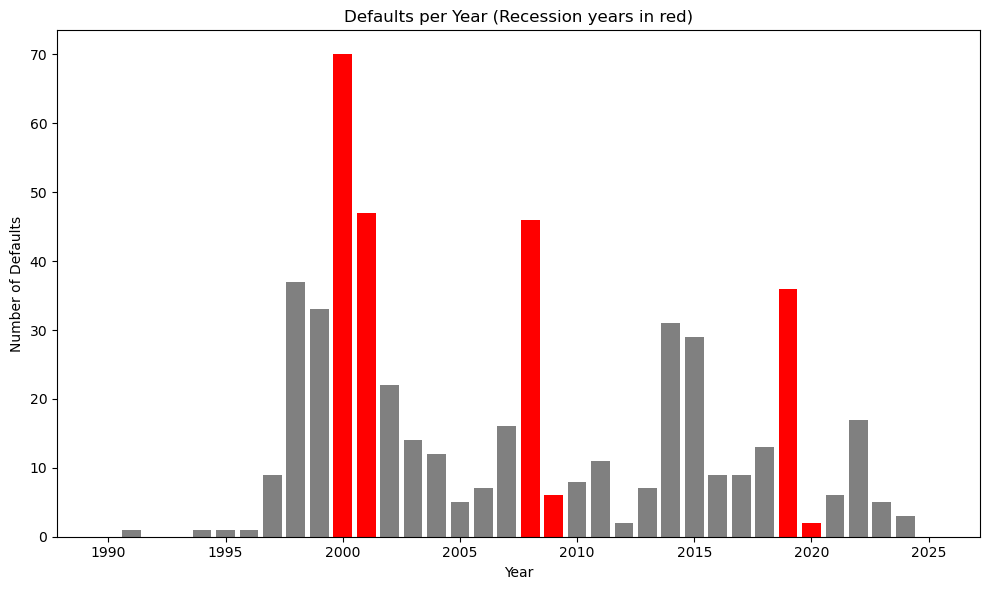

Defaults are overrepresented in recession years.


In [15]:
colors = defaults_per_year["year"].apply(
    lambda y: "red" if y in recession_years else "gray"
)

plt.figure(figsize=(10,6))
plt.bar(defaults_per_year["year"], defaults_per_year["defaults"], color=colors)
plt.xlabel("Year")
plt.ylabel("Number of Defaults")
plt.title("Defaults per Year (Recession years in red)")
plt.tight_layout()
plt.show()
print("Defaults are overrepresented in recession years.")

In [17]:
# group by the scale of firms
print(df["sale"].head())
print(df["sale"].min())
print(df["sale"].max())

0    451.395
1    504.990
2    589.328
3    782.123
4    918.036
Name: sale, dtype: float64
0.016
637959.0


In [22]:
df["size_group"] = pd.cut(
    df["sale"],
    bins=[-float("inf"),
          df["sale"].quantile(1/3),
          df["sale"].quantile(2/3),
          float("inf")],
    labels=["Small","Medium","Large"]
)

defaults_countby_size = df.groupby("size_group")["default"].agg(
    observations="count",
    defaults="sum"
)
print(defaults_countby_size)
print("\nDefaults are underrepresented in recession years.")

            observations  defaults
size_group                        
Small              12885       350
Medium             12883       117
Large              12885        49

Defaults are underrepresented in recession years.


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/531824393.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  defaults_countby_size = df.groupby("size_group")["default"].agg(


In [ ]:
#Step 2 - Single Factor Analysis

In [94]:
#variables group
profitability_risk_drivers = ["NIAT","NIMTA"]
leverage_risk_drivers = ["DBTMKTEQ", "DBTAT"]
liquidity_risk_drivers = ["ACTLCT", "CASHTA"]
size_risk_drivers = ["LOGSALE"]
other_risk_drivers = ["Altman_Z"] #zscore

In [95]:
vars8 = profitability_risk_drivers + leverage_risk_drivers \
        + liquidity_risk_drivers + size_risk_drivers \
        + other_risk_drivers

a = df[vars8 + ["default"]].corr()
a = a["default"]

print(a.drop("default"))

NIAT       -0.170725
NIMTA      -0.175630
DBTMKTEQ    0.066994
DBTAT       0.162527
ACTLCT     -0.011254
CASHTA     -0.024724
LOGSALE    -0.086345
Altman_Z   -0.005089
Name: default, dtype: float64


In [ ]:
#AUC of profitability_risk_drivers

In [96]:
display(Markdown(f"AUC of profitability risk drivers"))
for var in profitability_risk_drivers:
    auc = roc_auc_score(df["default"], df[var]) * 100
    print(f"AUC: {var}: {auc:.2f}%")

AUC of profitability risk drivers

AUC: NIAT: 10.86%
AUC: NIMTA: 11.24%


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/3511797997.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()
/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/3511797997.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()


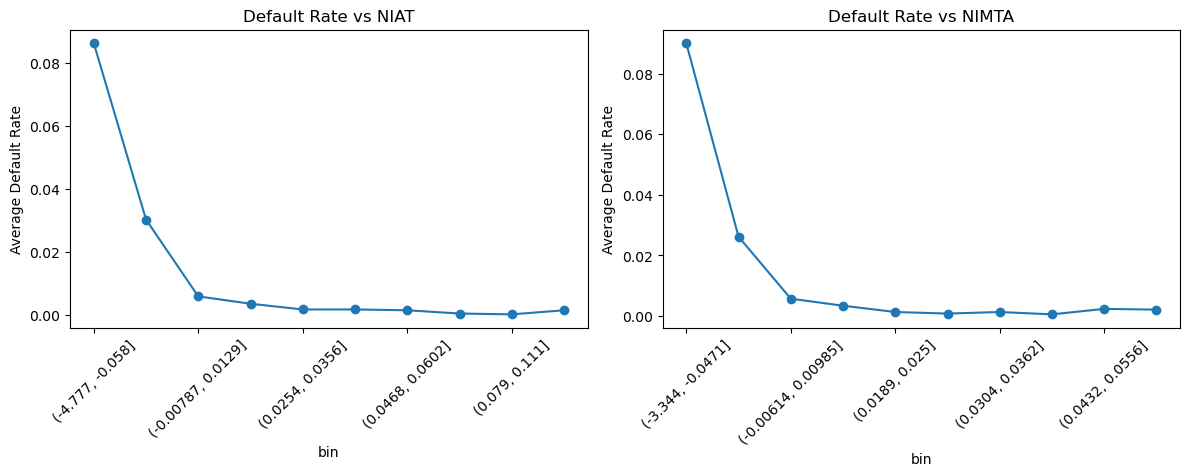

In [97]:
plt.figure(figsize=(12, 8))

for i, var in enumerate(profitability_risk_drivers, 1):
    df["bin"] = pd.qcut(df[var], 10, duplicates="drop")
    grouped = df.groupby("bin")["default"].mean()
    plt.subplot(2, 2, i)
    grouped.plot(marker="o")
    plt.title(f"Default Rate vs {var}")
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#As NIAT（NIMTA） increases, the predicted PD decreases. Firms with higher profitability（net income/ market value） are more capable of servicing their debt. This is consistent with expectations.
#

In [42]:
#AUC of leverage_risk_drivers

In [98]:
display(Markdown(f"AUC of leverage risk drivers"))
for var in leverage_risk_drivers:
    auc = roc_auc_score(df["default"], df[var]) * 100
    print(f"AUC: {var}: {auc:.2f}%")

AUC of leverage risk drivers

AUC: DBTMKTEQ: 82.51%
AUC: DBTAT: 83.50%


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/678243337.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()
/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/678243337.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()


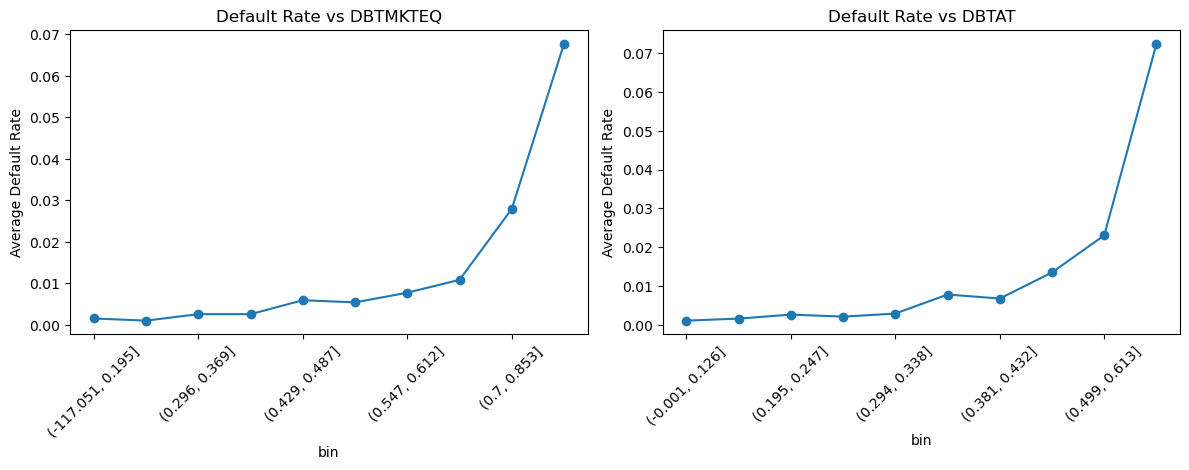

In [99]:
plt.figure(figsize=(12, 8))

for i, var in enumerate(leverage_risk_drivers, 1):
    df["bin"] = pd.qcut(df[var], 10, duplicates="drop")
    grouped = df.groupby("bin")["default"].mean()
    plt.subplot(2, 2, i)
    grouped.plot(marker="o")
    plt.title(f"Default Rate vs {var}")
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#As total debt increases, PD rises. Heavier debt loads increase financial leverage and the chance of distress. This is in line with economic intuition.

In [ ]:
#AUC of liquidity_risk_drivers

In [100]:
display(Markdown(f"AUC of leverage risk drivers"))
for var in liquidity_risk_drivers:
    auc = roc_auc_score(df["default"], df[var]) * 100
    print(f"AUC: {var}: {auc:.2f}%")

AUC of leverage risk drivers

AUC: ACTLCT: 38.97%
AUC: CASHTA: 41.87%


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/2411385728.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()
/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/2411385728.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()


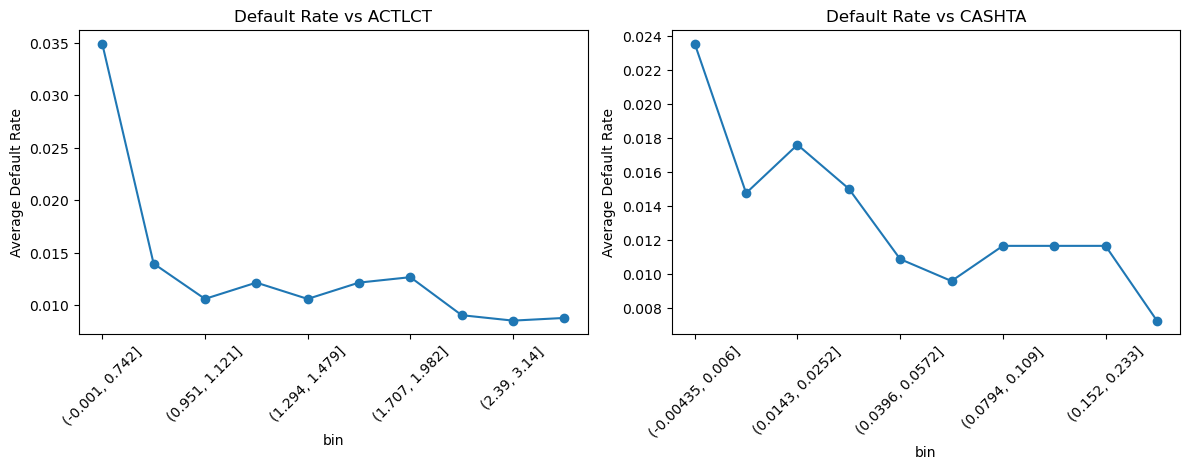

In [101]:
plt.figure(figsize=(12, 8))

for i, var in enumerate(liquidity_risk_drivers, 1):
    df["bin"] = pd.qcut(df[var], 10, duplicates="drop")
    grouped = df.groupby("bin")["default"].mean()
    plt.subplot(2, 2, i)
    grouped.plot(marker="o")
    plt.title(f"Default Rate vs {var}")
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [102]:
#Firms with a higher ACTLCT ratio tend to show lower PD. This suggests that stronger liquidity improves the ability to cover short-term obligations. This is consistent with expectations.
#Firms with a higher CASHTA ratio tend to show lower PD. The more cash means lower pressure for paying the loan, related to lower PD.This is consistent with expectations.

In [ ]:
#AUC of size_risk_drivers

In [103]:
display(Markdown(f"AUC of leverage risk drivers"))
for var in size_risk_drivers:
    auc = roc_auc_score(df["default"], df[var]) * 100
    print(f"AUC: {var}: {auc:.2f}%")

AUC of leverage risk drivers

AUC: LOGSALE: 27.85%


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/2579343988.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()


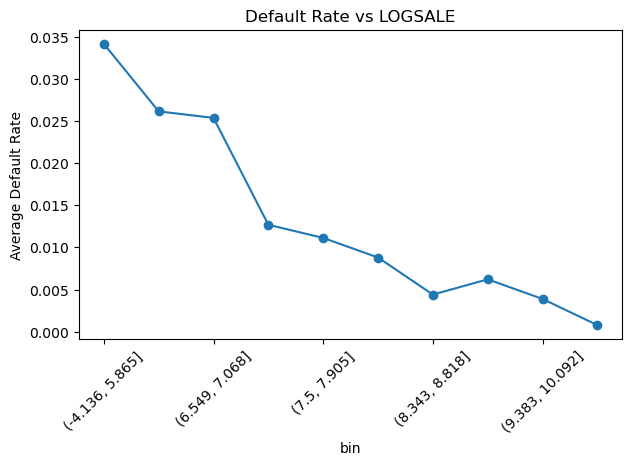

In [104]:
plt.figure(figsize=(12, 8))

for i, var in enumerate(size_risk_drivers, 1):
    df["bin"] = pd.qcut(df[var], 10, duplicates="drop")
    grouped = df.groupby("bin")["default"].mean()
    plt.subplot(2, 2, i)
    grouped.plot(marker="o")
    plt.title(f"Default Rate vs {var}")
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# As firm size increases, PD decreases. Larger companies are usually more diversified and have greater access to funding. This is consistent with expectations.

In [105]:
#AUC of z score

In [106]:
display(Markdown(f"AUC of leverage risk drivers"))
for var in other_risk_drivers:
    auc = roc_auc_score(df["default"], df[var]) * 100
    print(f"AUC: {var}: {auc:.2f}%")

AUC of leverage risk drivers

AUC: Altman_Z: 18.02%


/var/folders/dg/3ng4cdk958nb0f7fl02nfw3w0000gn/T/ipykernel_57223/103118706.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["default"].mean()


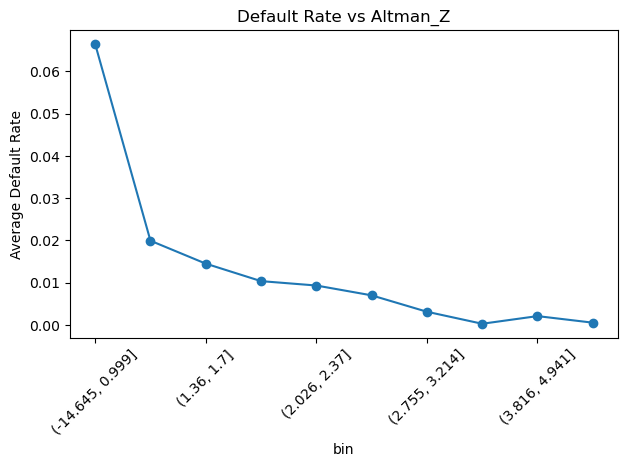

In [107]:
plt.figure(figsize=(12, 8))

for i, var in enumerate(other_risk_drivers, 1):
    df["bin"] = pd.qcut(df[var], 10, duplicates="drop")
    grouped = df.groupby("bin")["default"].mean()
    plt.subplot(2, 2, i)
    grouped.plot(marker="o")
    plt.title(f"Default Rate vs {var}")
    plt.ylabel("Average Default Rate")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# A higher zcore corresponds to lower PD.  A strong balance sheet and solid earnings performance indicate good financial health, which corresponds to lower default risk. That's consistent with expectations.

In [ ]:
#step3 Multi-factor Analysis

In [ ]:
#Model 1

In [108]:
factors = (
    profitability_risk_drivers
    + leverage_risk_drivers
    + liquidity_risk_drivers
    + size_risk_drivers
    + other_risk_drivers
)
y = df["default"]
x = df[factors]
x = sm.add_constant(x)

model1 = sm.Logit(y, x).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.057176
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                38653
Model:                          Logit   Df Residuals:                    38644
Method:                           MLE   Df Model:                            8
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                  0.1933
Time:                        18:36:50   Log-Likelihood:                -2210.0
converged:                       True   LL-Null:                       -2739.7
Covariance Type:            nonrobust   LLR p-value:                2.197e-223
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7897      0.265    -10.539      0.000      -3.308      -2.271
NIAT           1.3230      0

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [ ]:
# highest p value-ACTLCT

In [ ]:
# Model 2

In [109]:
factors_2 = ["NIAT","NIMTA","TDEBT","DBTAT","CASHTA","LOGSALE","Altman_Z"]
y = df["default"]
x = df[factors_2]
x = sm.add_constant(x)

model2 = sm.Logit(y, x).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.057095
         Iterations 12
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                38653
Model:                          Logit   Df Residuals:                    38645
Method:                           MLE   Df Model:                            7
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                  0.1945
Time:                        18:37:25   Log-Likelihood:                -2206.9
converged:                       True   LL-Null:                       -2739.7
Covariance Type:            nonrobust   LLR p-value:                7.620e-226
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3881      0.305    -11.106      0.000      -3.986      -2.790
NIAT           1.4381      0

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [ ]:
#highest p - LOGSALE

In [ ]:
#Model 3

In [110]:
factors_3 = ["NIAT","NIMTA","TDEBT","DBTAT","CASHTA","Altman_Z"]
y = df["default"]
x = df[factors_3]
x = sm.add_constant(x)

model3 = sm.Logit(y, x).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 0.057140
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                38653
Model:                          Logit   Df Residuals:                    38646
Method:                           MLE   Df Model:                            6
Date:                Thu, 25 Sep 2025   Pseudo R-squ.:                  0.1939
Time:                        18:37:54   Log-Likelihood:                -2208.6
converged:                       True   LL-Null:                       -2739.7
Covariance Type:            nonrobust   LLR p-value:                3.097e-226
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.9256      0.117    -33.443      0.000      -4.156      -3.696
NIAT           1.5330      0

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


In [111]:
print(model3.pvalues.round(7))

const       0.000000
NIAT        0.000006
NIMTA       0.000000
TDEBT       0.000002
DBTAT       0.000000
CASHTA      0.000008
Altman_Z    0.000000
dtype: float64


In [ ]:
# all variables are statistically significant

In [112]:
pds1 = model1.predict()
auc1 = roc_auc_score(df["default"], pds1)

pds2 = model2.predict()
auc2 = roc_auc_score(df["default"], pds2)

pds3 = model3.predict()
auc3 = roc_auc_score(df["default"], pds3)

display(Markdown(f"### Model 1 (8 factors) AUC: {auc1*100:.2f}%"))
display(Markdown(f"### Model 2 (7 factors) AUC: {auc2*100:.2f}%"))
display(Markdown(f"### Model 3 (6 factors) AUC: {auc3*100:.2f}%"))

/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/PyCharmMiscProject/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


### Model 1 (8 factors) AUC: 89.86%

### Model 2 (7 factors) AUC: 89.82%

### Model 3 (6 factors) AUC: 89.92%

In [ ]:
# The AUC stayed around 90% across all models, showing that removed variables (e.g., ACTLCT, LOGSALE) added little value. The final 6-factor model is more parsimonious, with all variables significant, and its AUC slightly higher than the full model.

In [ ]:
#step4- Apple and Eastman Kodak

In [113]:
apple = df[df["entity_pname"].str.contains("Apple", case=False, na=False)].sort_values("datadate")

kodak = df[df["entity_pname"].str.contains("Kodak", case=False, na=False)].sort_values("datadate")

In [114]:
factors_final = ["NIAT","NIMTA","TDEBT","DBTAT","CHLCT","Altman_Z"]

X_apple = apple[factors_final]
X_apple = sm.add_constant(X_apple)
apple["PD"] = model.predict(X_apple)

X_kodak = kodak[factors_final]
X_kodak = sm.add_constant(X_kodak)
kodak["PD"] = model.predict(X_kodak)


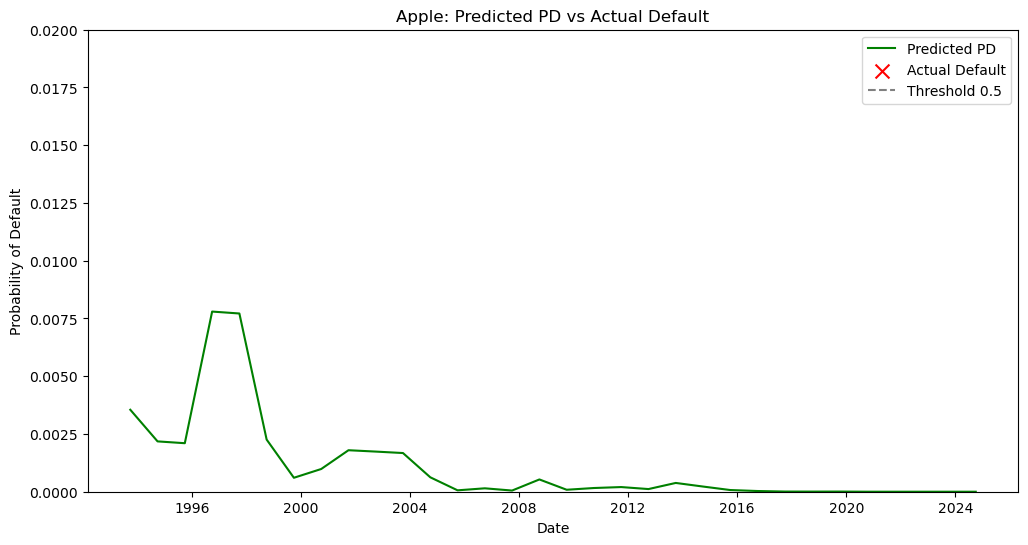

In [115]:
plt.figure(figsize=(12,6))
plt.plot(apple["datadate"], apple["PD"], label="Predicted PD", color="green")

defaults = apple[apple["dflt_flag"]==1]
plt.scatter(defaults["datadate"], defaults["PD"], color="red", marker="x", s=100, label="Actual Default")

plt.axhline(0.5, color="gray", linestyle="--", label="Threshold 0.5")
plt.title("Apple: Predicted PD vs Actual Default")
plt.xlabel("Date")
plt.ylabel("Probability of Default")
plt.ylim(0, 0.02)
plt.legend()
plt.show()

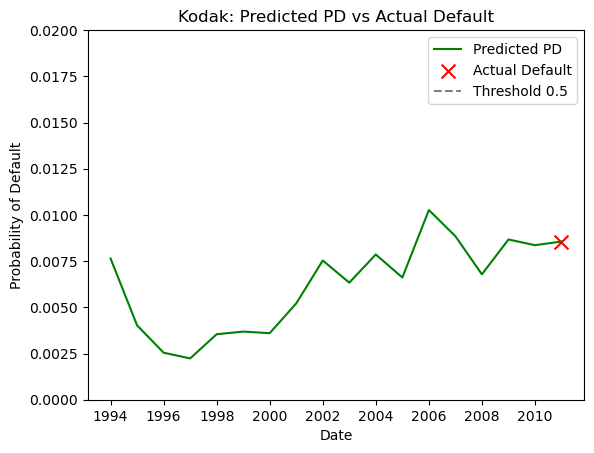

In [116]:
plt.plot(kodak["datadate"], kodak["PD"], label="Predicted PD", color="green")

# 在真实违约点标记红色叉号
defaults = kodak[kodak["dflt_flag"]==1]
plt.scatter(defaults["datadate"], defaults["PD"], color="red", marker="x", s=100, label="Actual Default")

# 美化
plt.axhline(0.5, color="gray", linestyle="--", label="Threshold 0.5")  # 可选：画一条参考线
plt.title("Kodak: Predicted PD vs Actual Default")
plt.xlabel("Date")
plt.ylabel("Probability of Default")
plt.ylim(0, 0.02)
plt.legend()
plt.show()

In [ ]:
# Although the absolute predicted probabilities are very low（between 0 ～ 0.02）, the relative trends correctly reflect the evolution of credit risk:
# Apple’s PD increased during its crisis period but is close to zero today.
# Kodak’s PD was low a decade earlier but rose significantly prior to its default.